# Emotion Detection Model — Evaluation
**Model:** `melisaolivia18/emotion-detection-roberta`  
**Dataset:** GoEmotions + ISEAR + EmpatheticDialogues (5-class unified)  
**Split:** test.csv (held-out, never seen during training)

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import RobertaTokenizer, RobertaForSequenceClassification
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from huggingface_hub import login
from kaggle_secrets import UserSecretsClient

print("GPU available:", torch.cuda.is_available())
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

GPU available: True
Device: cuda


In [2]:
# ── HuggingFace Login ─────────────────────────────────────────────────────────
user_secrets = UserSecretsClient()
hf_token = user_secrets.get_secret("HF_TOKEN")
login(token=hf_token)
print("Logged in to HuggingFace Hub")

Logged in to HuggingFace Hub


In [3]:
# ── Config ────────────────────────────────────────────────────────────────────
MODEL_ID   = "melisaolivia18/emotion-detection-roberta"
TEST_PATH  = "/kaggle/input/datasets/melisaolivia/nlp-music-music-cleaned/emotion-detection/test.csv"
MAX_LEN    = 128
BATCH_SIZE = 32   # larger batch is fine for inference only

EMOTION_CATEGORIES = ['angry', 'anxious', 'content', 'joyful', 'sad']
label2id = {l: i for i, l in enumerate(EMOTION_CATEGORIES)}
id2label = {i: l for l, i in label2id.items()}

In [4]:
# ── Load Model & Tokenizer from Hub ──────────────────────────────────────────
print(f"Loading model: {MODEL_ID}")
tokenizer = RobertaTokenizer.from_pretrained(MODEL_ID)
model     = RobertaForSequenceClassification.from_pretrained(MODEL_ID)
model.to(DEVICE)
model.eval()
print("Model loaded and ready")

Loading model: melisaolivia18/emotion-detection-roberta


tokenizer_config.json:   0%|          | 0.00/359 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/955 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model loaded and ready


In [5]:
# ── Load Test Set ─────────────────────────────────────────────────────────────
test_df = pd.read_csv(TEST_PATH)
test_df = test_df[test_df["label"].isin(EMOTION_CATEGORIES)].reset_index(drop=True)
test_df["label_id"] = test_df["label"].map(label2id)

print(f"Test rows : {len(test_df)}")
print(test_df["label"].value_counts())

Test rows : 2380
label
sad        655
angry      556
joyful     454
anxious    367
content    348
Name: count, dtype: int64


In [6]:
# ── Dataset & DataLoader ──────────────────────────────────────────────────────
class EmotionDataset(Dataset):
    def __init__(self, texts, labels):
        self.encodings = tokenizer(
            texts.tolist(),
            padding="max_length",
            truncation=True,
            max_length=MAX_LEN,
            return_tensors="pt"
        )
        self.labels = torch.tensor(labels.tolist(), dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids":      self.encodings["input_ids"][idx],
            "attention_mask": self.encodings["attention_mask"][idx],
            "labels":         self.labels[idx]
        }

test_dataset = EmotionDataset(test_df["text"], test_df["label_id"])
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
print(f"Total batches : {len(test_loader)}")

Total batches : 75


In [7]:
# ── Run Inference ─────────────────────────────────────────────────────────────
all_preds  = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels         = batch["labels"]

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds   = torch.argmax(outputs.logits, dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

y_pred = np.array(all_preds)
y_true = np.array(all_labels)

print(f"Inference complete. Total samples: {len(y_true)}")

Inference complete. Total samples: 2380


In [8]:
# ── Overall Metrics ───────────────────────────────────────────────────────────
acc                             = accuracy_score(y_true, y_pred)
prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(y_true, y_pred, average="macro",    zero_division=0)
prec_wt,   rec_wt,   f1_wt,   _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)

print("=" * 45)
print("          OVERALL METRICS (Test Set)")
print("=" * 45)
print(f"  Accuracy           : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Macro  Precision   : {prec_macro:.4f}")
print(f"  Macro  Recall      : {rec_macro:.4f}")
print(f"  Macro  F1-Score    : {f1_macro:.4f}")
print(f"  Weighted Precision : {prec_wt:.4f}")
print(f"  Weighted Recall    : {rec_wt:.4f}")
print(f"  Weighted F1-Score  : {f1_wt:.4f}")
print("=" * 45)

          OVERALL METRICS (Test Set)
  Accuracy           : 0.6580  (65.80%)
  Macro  Precision   : 0.6605
  Macro  Recall      : 0.6535
  Macro  F1-Score    : 0.6558
  Weighted Precision : 0.6582
  Weighted Recall    : 0.6580
  Weighted F1-Score  : 0.6570


In [9]:
# ── Per-Class Classification Report ──────────────────────────────────────────
print("\n=== Per-Class Classification Report ===")
report = classification_report(
    y_true, y_pred,
    target_names=EMOTION_CATEGORIES,
    zero_division=0,
    digits=4
)
print(report)


=== Per-Class Classification Report ===
              precision    recall  f1-score   support

       angry     0.6224    0.6996    0.6588       556
     anxious     0.7364    0.7003    0.7179       367
     content     0.6013    0.5201    0.5578       348
      joyful     0.6879    0.7137    0.7005       454
         sad     0.6546    0.6336    0.6439       655

    accuracy                         0.6580      2380
   macro avg     0.6605    0.6535    0.6558      2380
weighted avg     0.6582    0.6580    0.6570      2380



In [10]:
# ── Per-Class Metrics Table (clean DataFrame for paper) ──────────────────────
prec_per, rec_per, f1_per, sup_per = precision_recall_fscore_support(
    y_true, y_pred,
    labels=list(range(len(EMOTION_CATEGORIES))),
    zero_division=0
)

metrics_df = pd.DataFrame({
    "Emotion"   : EMOTION_CATEGORIES,
    "Precision" : np.round(prec_per, 4),
    "Recall"    : np.round(rec_per,  4),
    "F1-Score"  : np.round(f1_per,   4),
    "Support"   : sup_per.astype(int)
})

# Append macro & weighted averages as footer rows
metrics_df = pd.concat([
    metrics_df,
    pd.DataFrame([{
        "Emotion"   : "Macro Avg",
        "Precision" : round(prec_macro, 4),
        "Recall"    : round(rec_macro,  4),
        "F1-Score"  : round(f1_macro,   4),
        "Support"   : len(y_true)
    }]),
    pd.DataFrame([{
        "Emotion"   : "Weighted Avg",
        "Precision" : round(prec_wt, 4),
        "Recall"    : round(rec_wt,  4),
        "F1-Score"  : round(f1_wt,   4),
        "Support"   : len(y_true)
    }])
], ignore_index=True)

print("\n=== Per-Class Metrics Table ===")
print(metrics_df.to_string(index=False))

# Export to CSV for paper
metrics_df.to_csv("evaluation_metrics.csv", index=False)
print("\nSaved → evaluation_metrics.csv")


=== Per-Class Metrics Table ===
     Emotion  Precision  Recall  F1-Score  Support
       angry     0.6224  0.6996    0.6588      556
     anxious     0.7364  0.7003    0.7179      367
     content     0.6013  0.5201    0.5578      348
      joyful     0.6879  0.7137    0.7005      454
         sad     0.6546  0.6336    0.6439      655
   Macro Avg     0.6605  0.6535    0.6558     2380
Weighted Avg     0.6582  0.6580    0.6570     2380

Saved → evaluation_metrics.csv


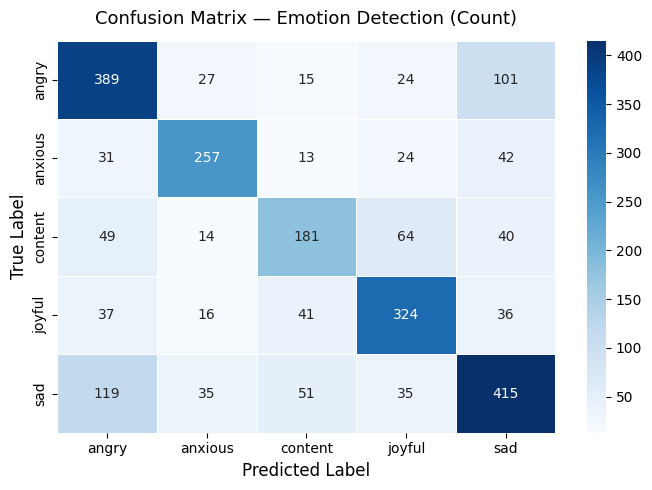

Saved → confusion_matrix_count.png


In [11]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred, labels=list(range(len(EMOTION_CATEGORIES))))

# Raw counts
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=EMOTION_CATEGORIES,
    yticklabels=EMOTION_CATEGORIES,
    linewidths=0.5, linecolor="white",
    ax=ax
)
ax.set_xlabel("Predicted Label", fontsize=12)
ax.set_ylabel("True Label",      fontsize=12)
ax.set_title("Confusion Matrix — Emotion Detection (Count)", fontsize=13, pad=12)
plt.tight_layout()
plt.savefig("confusion_matrix_count.png", dpi=200)
plt.show()
print("Saved → confusion_matrix_count.png")

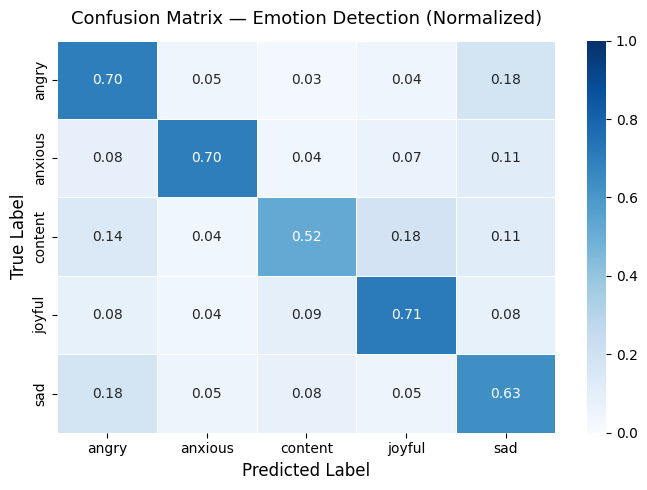

Saved → confusion_matrix_normalized.png


In [12]:
# ── Confusion Matrix (Normalized %) — better for paper figures ───────────────
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # normalize by true class

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    cm_norm, annot=True, fmt=".2f", cmap="Blues",
    xticklabels=EMOTION_CATEGORIES,
    yticklabels=EMOTION_CATEGORIES,
    vmin=0, vmax=1,
    linewidths=0.5, linecolor="white",
    ax=ax
)
ax.set_xlabel("Predicted Label", fontsize=12)
ax.set_ylabel("True Label",      fontsize=12)
ax.set_title("Confusion Matrix — Emotion Detection (Normalized)", fontsize=13, pad=12)
plt.tight_layout()
plt.savefig("confusion_matrix_normalized.png", dpi=200)
plt.show()
print("Saved → confusion_matrix_normalized.png")

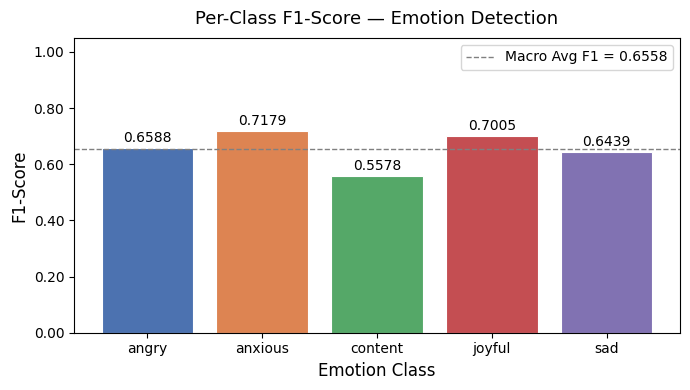

Saved → f1_per_class.png


In [13]:
# ── Per-Class F1 Bar Chart — for paper visualization ─────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    EMOTION_CATEGORIES, f1_per,
    color=["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"],
    edgecolor="white", linewidth=0.8
)
ax.set_ylim(0, 1.05)
ax.set_xlabel("Emotion Class", fontsize=12)
ax.set_ylabel("F1-Score",      fontsize=12)
ax.set_title("Per-Class F1-Score — Emotion Detection", fontsize=13, pad=10)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))
ax.axhline(y=f1_macro, color="gray", linestyle="--", linewidth=1, label=f"Macro Avg F1 = {f1_macro:.4f}")
ax.legend(fontsize=10)

for bar, val in zip(bars, f1_per):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{val:.4f}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.savefig("f1_per_class.png", dpi=200)
plt.show()
print("Saved → f1_per_class.png")

In [14]:
# ── Summary Print (copy-paste ready for paper table) ─────────────────────────
print("\n" + "=" * 50)
print("   FINAL RESULTS SUMMARY — copy to paper")
print("=" * 50)
print(f"  Accuracy           : {acc*100:.2f}%")
print(f"  Macro Precision    : {prec_macro*100:.2f}%")
print(f"  Macro Recall       : {rec_macro*100:.2f}%")
print(f"  Macro F1-Score     : {f1_macro*100:.2f}%")
print(f"  Weighted F1-Score  : {f1_wt*100:.2f}%")
print("─" * 50)
for i, emo in enumerate(EMOTION_CATEGORIES):
    print(f"  {emo:<10} P={prec_per[i]:.4f}  R={rec_per[i]:.4f}  F1={f1_per[i]:.4f}  N={sup_per[i]}")
print("=" * 50)
print("Output files:")
print("  evaluation_metrics.csv")
print("  confusion_matrix_count.png")
print("  confusion_matrix_normalized.png")
print("  f1_per_class.png")


   FINAL RESULTS SUMMARY — copy to paper
  Accuracy           : 65.80%
  Macro Precision    : 66.05%
  Macro Recall       : 65.35%
  Macro F1-Score     : 65.58%
  Weighted F1-Score  : 65.70%
──────────────────────────────────────────────────
  angry      P=0.6224  R=0.6996  F1=0.6588  N=556
  anxious    P=0.7364  R=0.7003  F1=0.7179  N=367
  content    P=0.6013  R=0.5201  F1=0.5578  N=348
  joyful     P=0.6879  R=0.7137  F1=0.7005  N=454
  sad        P=0.6546  R=0.6336  F1=0.6439  N=655
Output files:
  evaluation_metrics.csv
  confusion_matrix_count.png
  confusion_matrix_normalized.png
  f1_per_class.png
